[2026-07-23 14:21:12] [info     ] 【本地自测 v2_no_future】
[2026-07-23 14:21:12] [info     ] 训练窗口: 2022-12-31 ~ 2023-12-31
[2026-07-23 14:21:12] [info     ] build_features 2022-12-31 ~ 2023-12-31 need_label=True
[2026-07-23 14:21:55] [info     ] 量价完成 rows=568253 t=42.6s
[2026-07-23 14:21:57] [info     ] 衍生特征完成 t=2.2s
[2026-07-23 14:21:59] [info     ] 财务完成 rows=1414573 t=1.7s
[2026-07-23 14:22:00] [info     ] 缺失值处理完成 t=0.2s
[2026-07-23 14:22:00] [info     ] 特征完成 rows=521446 cols=31 t=47.5s
[2026-07-23 14:22:00] [info     ] 训练集 rows=519248 features=31 label_mean=-0.000019
[2026-07-23 14:40:57] [info     ] 模型训练完成 best_iteration=99 t=1137.1s
[2026-07-23 14:40:57] [info     ] 开始预测: 2024-01-01 ~ 2024-12-31
[2026-07-23 14:40:57] [info     ] build_features 2024-01-01 ~ 2024-12-31 need_label=False
[2026-07-23 14:41:40] [info     ] 量价完成 rows=567791 t=43.1s
[2026-07-23 14:41:43] [info     ] 衍生特征完成 t=2.3s
[2026-07-23 14:41:44] [info     ] 财务完成 rows=1417811 t=1.7s
[2026-07-23 14:41:49] [info     ] 缺失值处理

时段,IC
2024-01-15~2024-02-08,-0.0040
2024-09-24~2024-10-08,0.0632

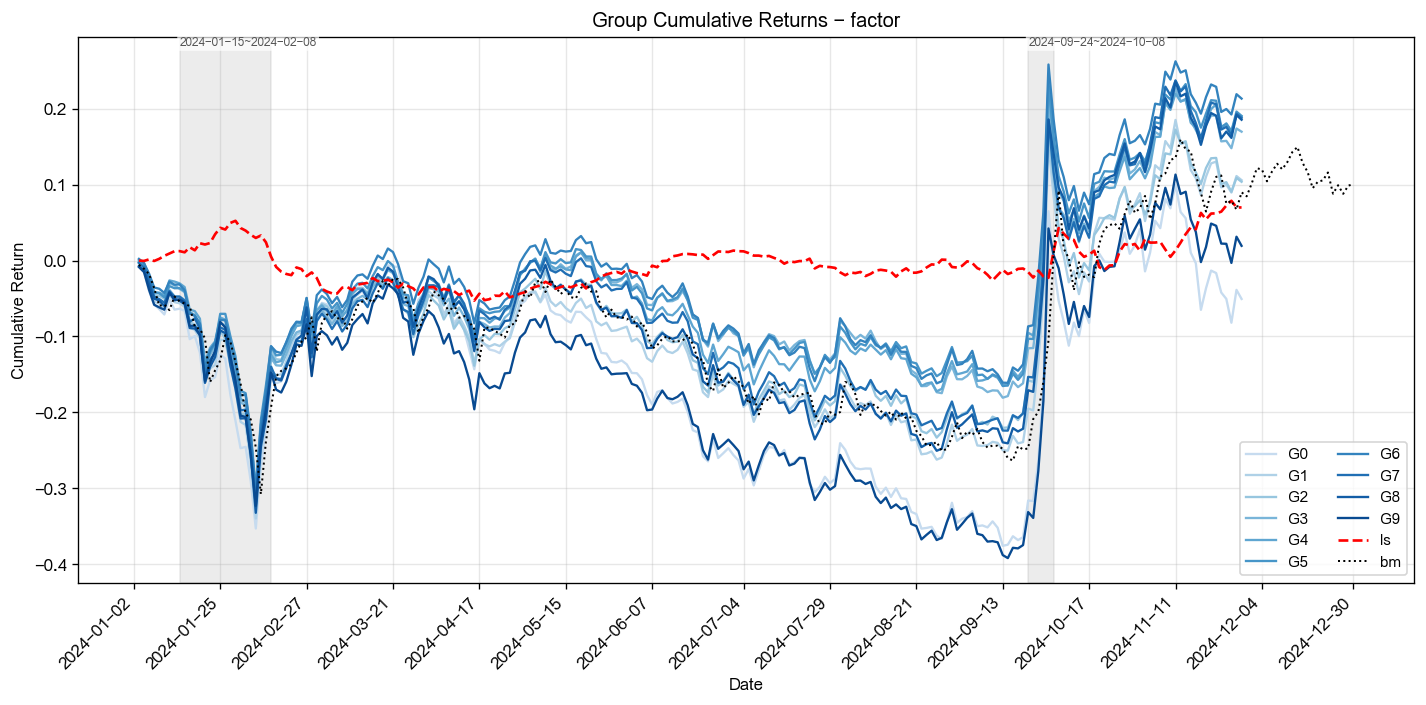
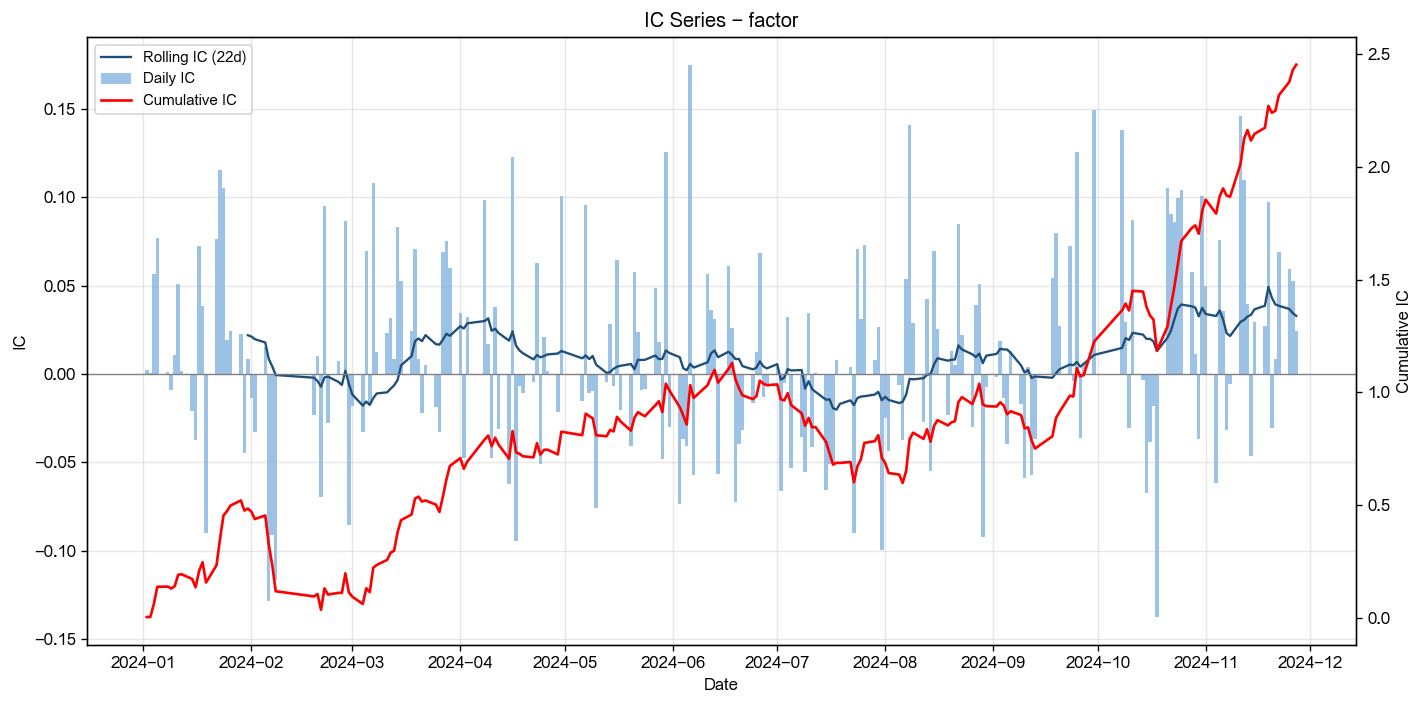
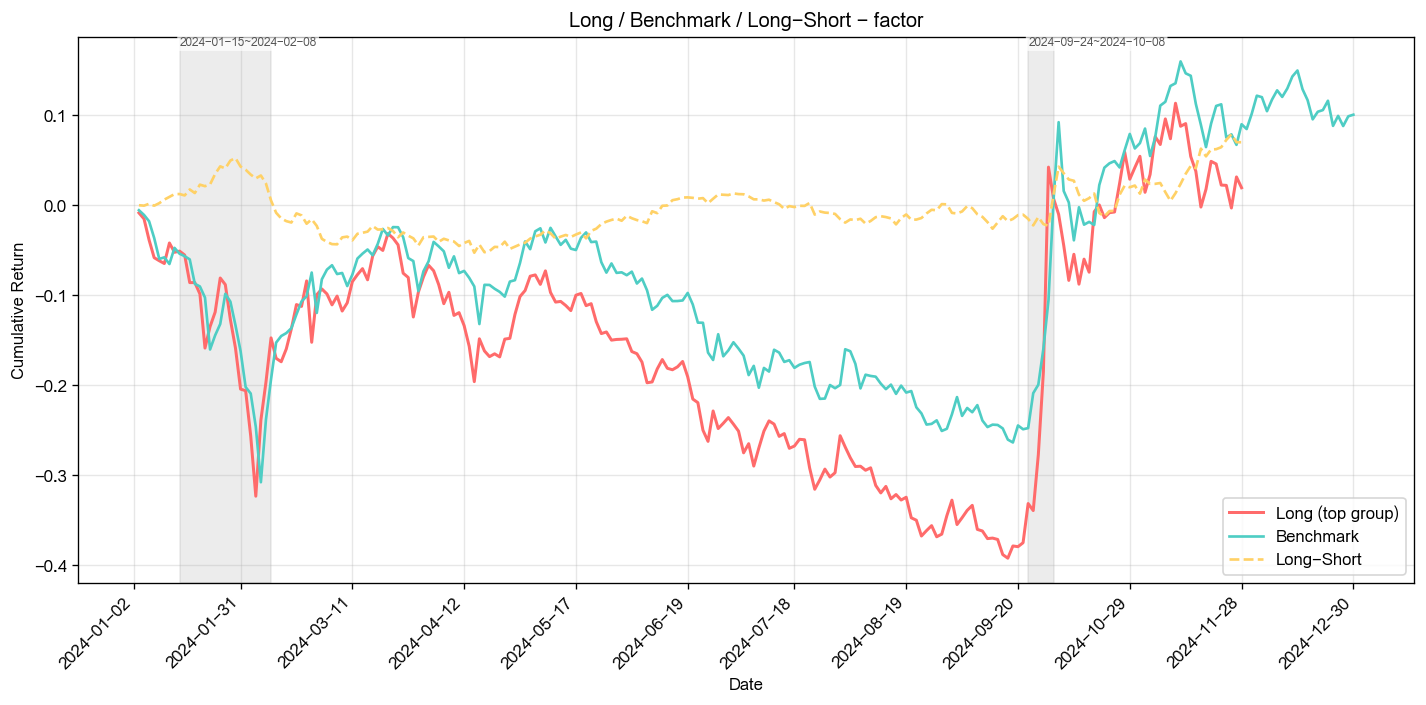
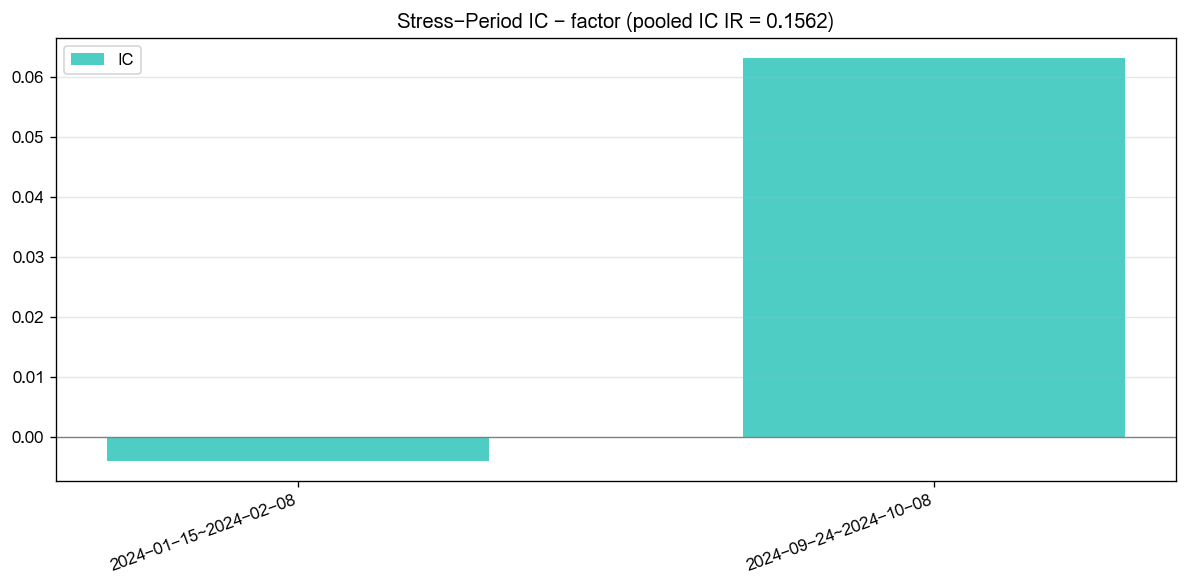
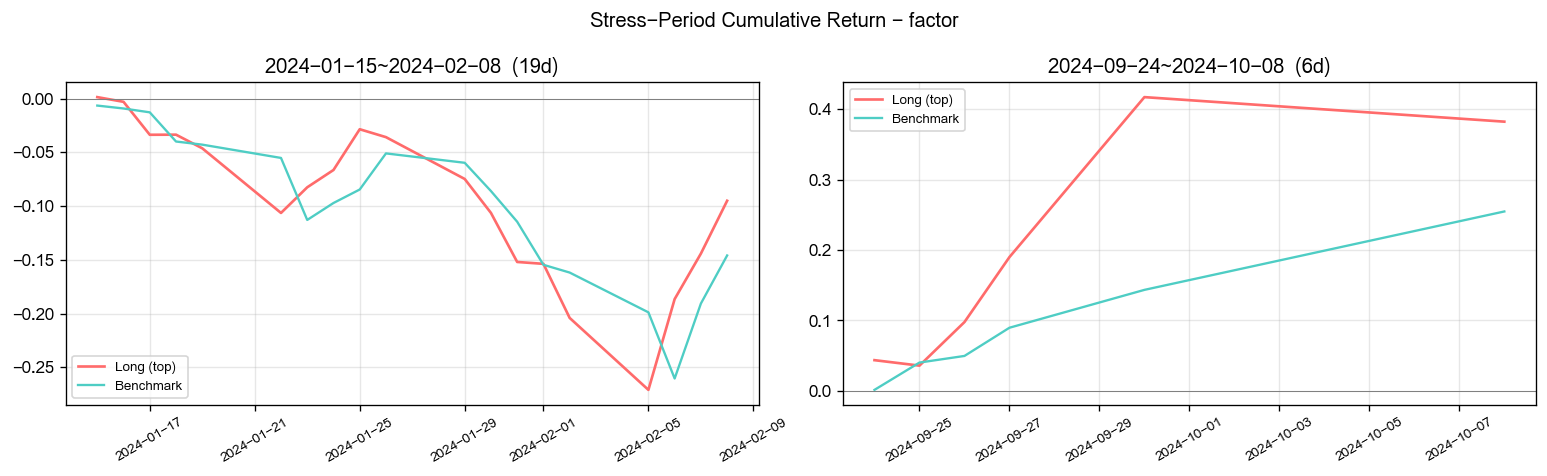

[2026-07-23 14:43:45] [info     ] ========== 因子池回归 ==========
[2026-07-23 14:43:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-30 instrument_count=1206 rows=296765 start_date=2024-01-02
[2026-07-23 14:43:46] [info     ] 获取收益率数据, 耗时: 1.1971 秒
[2026-07-23 14:43:48] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.7939 秒
[2026-07-23 14:43:48] [info     ] 统计 回归结果, 耗时: 0.0102 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9899,0.0448,0.0225,1.0000
2,factor,1.7262,0.0107,0.0062,1.0000
3,amount,1.6560,0.0157,0.0095,0.9000
4,netflow_amount_rate_main,1.5131,0.0098,0.0065,1.0000
5,netflow_amount_main,1.5087,0.0247,0.0164,1.0000
6,gross_profit_rate_ttm,1.5017,0.0067,0.0045,1.0000
7,net_profit_rate_ttm,1.4818,0.0039,0.0027,0.8000
8,pb,1.4733,0.0100,0.0068,0.9000
9,cci_14,1.4716,0.0345,0.0235,1.0000
10,ps_ttm,1.4666,0.0037,0.0025,0.9000

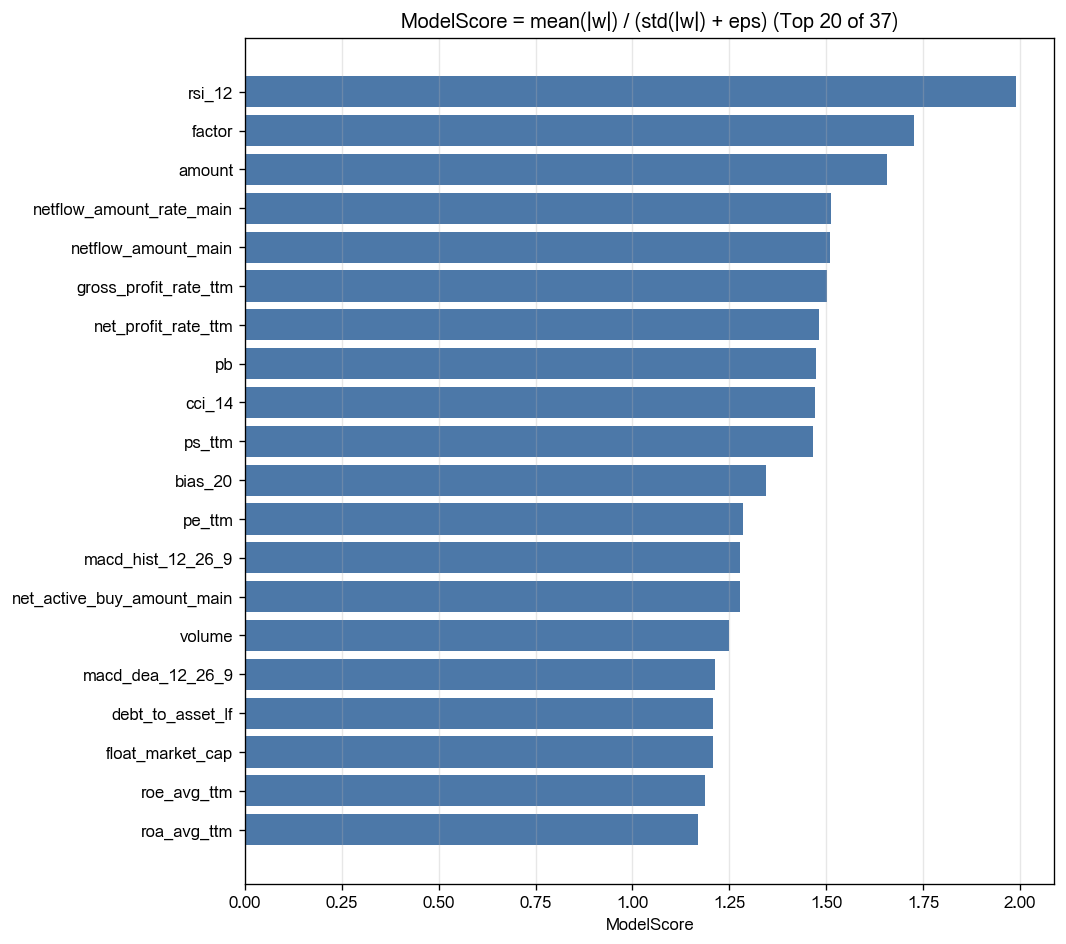
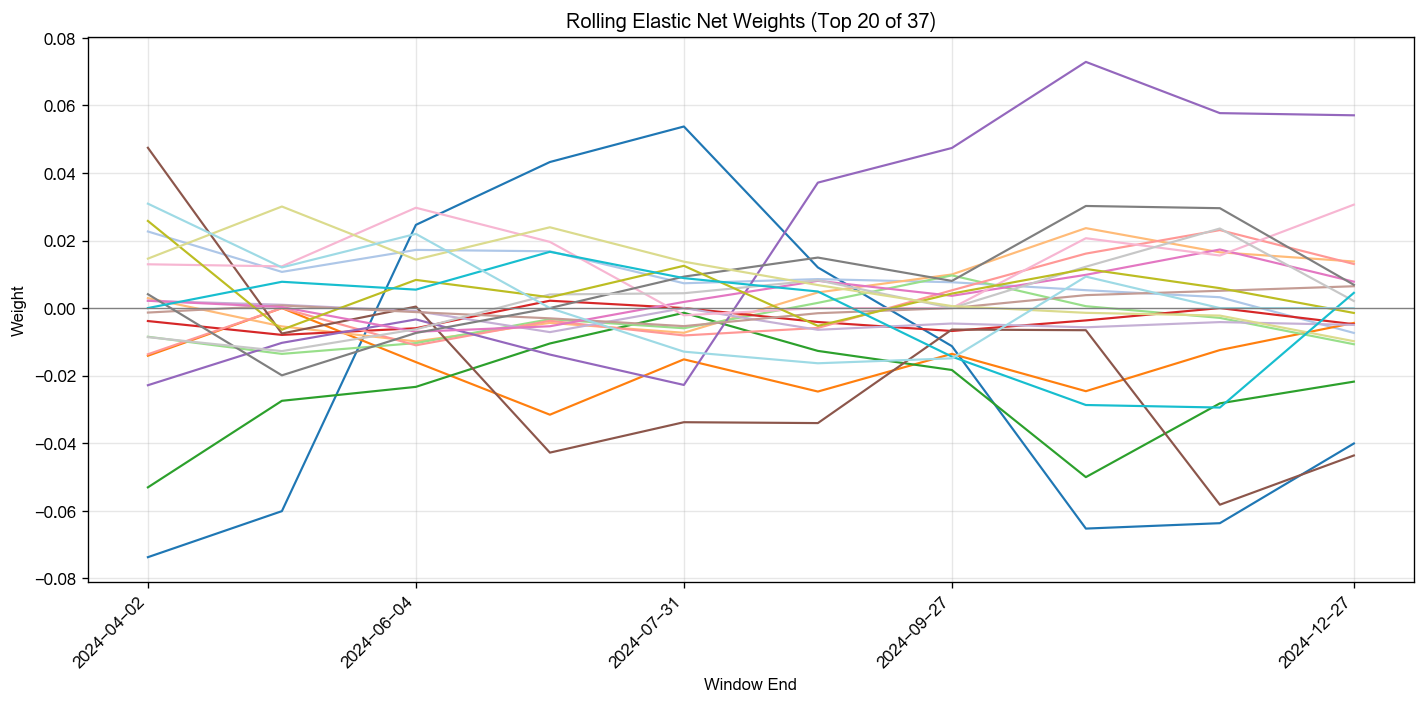
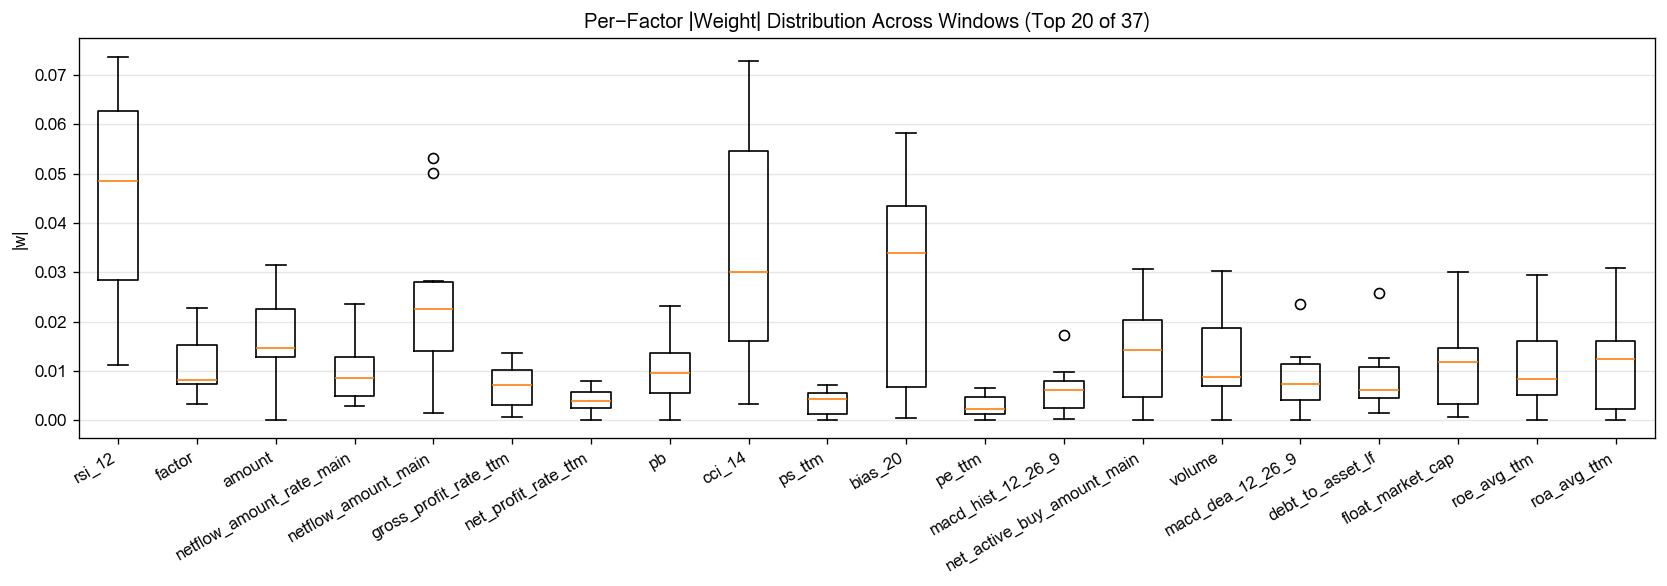
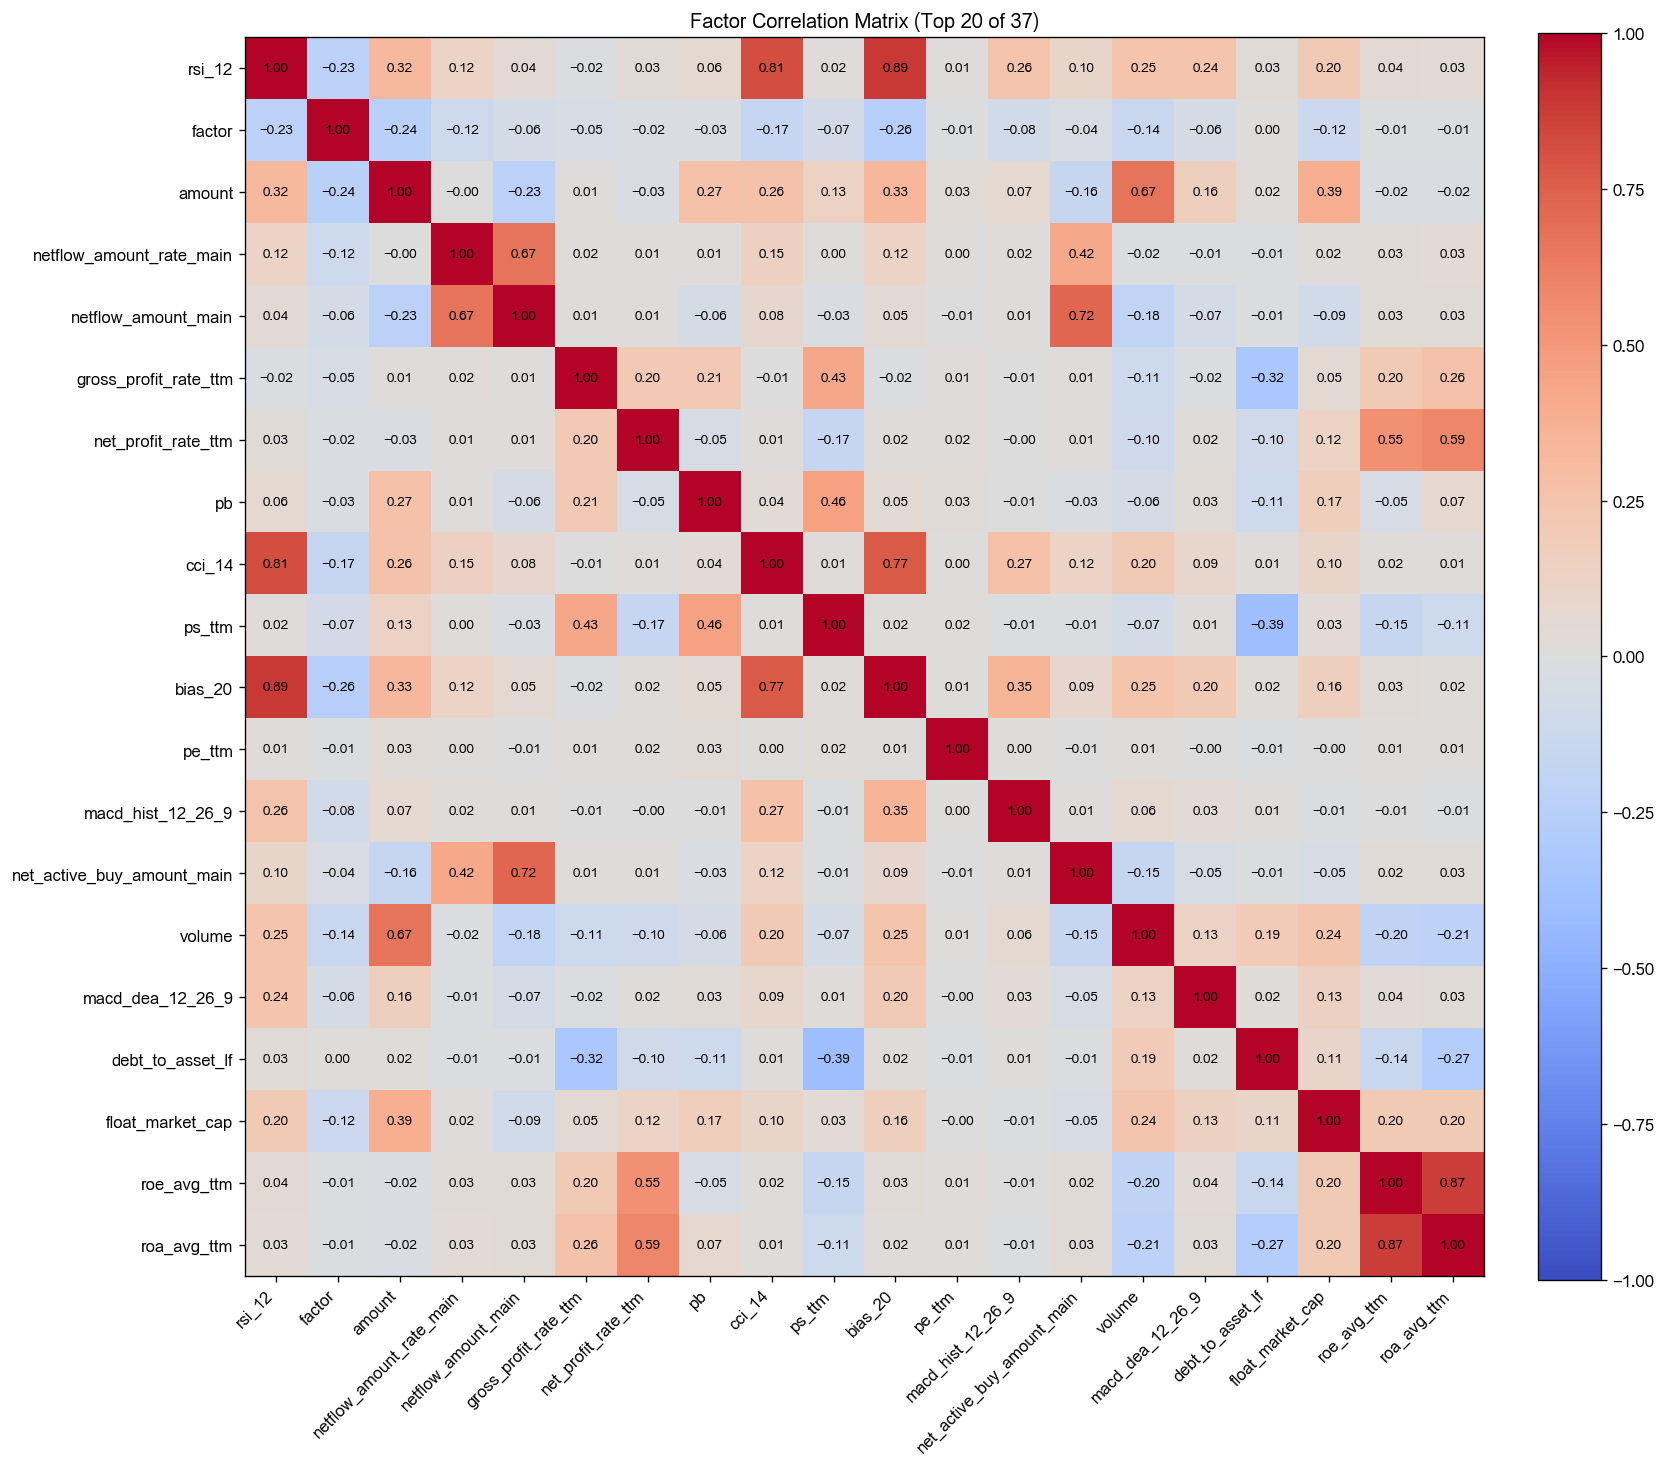

[2026-07-23 14:43:51] [warning  ] 返回的Outputs实例(size=34353288) 大于 64K, 将不会被缓存
[2026-07-23 14:43:51] [info     ] bigalpha_eval.v4 运行完成 [116.676s].
[2026-07-23 14:43:51] [info     ] 【完成】


In [6]:
def main(datasources, start_date, end_date):
    """
    AI因子挖掘 - XGBoost多源特征因子 v2_no_future

    修复点：
    1. 预测阶段不计算下一日 label，避免未来函数嫌疑
    2. 训练窗口严格早于预测 start_date
    3. main 只返回 date / instrument / factor 三列
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    eval_start = pd.to_datetime(start_date)
    train_end_dt = min(pd.Timestamp("2023-12-31"), eval_start - pd.Timedelta(days=1))
    train_start_dt = max(pd.Timestamp("2019-01-01"), train_end_dt - pd.Timedelta(days=365))

    TRAIN_START = train_start_dt.strftime("%Y-%m-%d")
    TRAIN_END = train_end_dt.strftime("%Y-%m-%d")

    fin_raw_cols = [
        "operating_revenue",
        "net_profit_to_parent_shareholders",
        "total_assets",
        "total_equity_to_parent_shareholders",
    ]

    def build_features(financial_table, bar1m_table, sd, ed, need_label=False):
        t0 = time.time()
        logger.info("build_features %s ~ %s need_label=%s", sd, ed, need_label)

        bar_start = pd.to_datetime(sd) - pd.Timedelta(days=30)

        bar_sql = f"""
        SELECT
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS date,
            instrument,
            ARG_MIN(open, date) AS open,
            MAX(high) AS high,
            MIN(low) AS low,
            ARG_MAX(close, date) AS close,
            SUM(volume) AS volume,
            SUM(amount) AS amount,
            (MAX(high) - MIN(low)) / NULLIF(ARG_MIN(open, date), 0) AS intraday_range,
            (ARG_MAX(close, date) - MIN(low)) / NULLIF(MAX(high) - MIN(low), 0.0001) AS close_position,
            AVG((ask_price1 - bid_price1) / NULLIF((ask_price1 + bid_price1) / 2.0, 0)) AS avg_spread,
            AVG(
                (COALESCE(bid_volume1,0)*1.0 + COALESCE(bid_volume2,0)*0.7 +
                 COALESCE(bid_volume3,0)*0.5 + COALESCE(bid_volume4,0)*0.3 +
                 COALESCE(bid_volume5,0)*0.1)
                / NULLIF(
                    COALESCE(bid_volume1,0)*1.0 + COALESCE(bid_volume2,0)*0.7 +
                    COALESCE(bid_volume3,0)*0.5 + COALESCE(bid_volume4,0)*0.3 +
                    COALESCE(bid_volume5,0)*0.1 +
                    COALESCE(ask_volume1,0)*1.0 + COALESCE(ask_volume2,0)*0.7 +
                    COALESCE(ask_volume3,0)*0.5 + COALESCE(ask_volume4,0)*0.3 +
                    COALESCE(ask_volume5,0)*0.1, 1)
            ) AS orderbook_imbalance,
            (STDDEV_SAMP(close) / NULLIF(AVG(close), 0)) AS intraday_dispersion,
            ((MAX(high) - MIN(low)) / NULLIF(ARG_MIN(open, date), 0))
                / NULLIF(SUM(amount), 0) * 1e8 AS amihud_proxy
        FROM {bar1m_table}
        WHERE ask_price1 > 0 AND bid_price1 > 0
        GROUP BY strftime(date, '%Y-%m-%d'), instrument
        ORDER BY instrument, strftime(date, '%Y-%m-%d')
        """

        bar = dai.query(
            bar_sql,
            filters={"date": [bar_start, ed]},
            compression=True,
        ).df()

        bar["date"] = pd.to_datetime(bar["date"])

        numeric_bar_cols = [
            "open", "high", "low", "close", "volume", "amount",
            "intraday_range", "close_position", "avg_spread",
            "orderbook_imbalance", "intraday_dispersion", "amihud_proxy",
        ]

        for col in numeric_bar_cols:
            if col in bar:
                bar[col] = pd.to_numeric(bar[col], errors="coerce")

        bar = bar.sort_values(["instrument", "date"]).reset_index(drop=True)
        logger.info("量价完成 rows=%d t=%.1fs", len(bar), time.time() - t0)

        t1 = time.time()
        g = bar.groupby("instrument", group_keys=False)

        bar["ret_1d"] = g["close"].pct_change()

        for n in [5, 10, 20]:
            bar[f"momentum_{n}d"] = bar["close"] / g["close"].shift(n) - 1

        bar["reversal_5d"] = -bar["ret_1d"].shift(1)

        for n in [5, 20]:
            bar[f"volatility_{n}d"] = g["ret_1d"].transform(
                lambda x: x.rolling(n, min_periods=3).std()
            )

        for n in [5, 20]:
            avg_v = g["volume"].transform(
                lambda x: x.rolling(n, min_periods=3).mean()
            )
            bar[f"volume_ratio_{n}d"] = bar["volume"] / (avg_v + 1) - 1

        avg_a = g["amount"].transform(
            lambda x: x.rolling(20, min_periods=3).mean()
        )
        bar["amount_ratio_20d"] = bar["amount"] / (avg_a + 1) - 1

        logger.info("衍生特征完成 t=%.1fs", time.time() - t1)

        if need_label:
            # 只在训练阶段计算下一日收益。
            # 预测阶段 need_label=False，完全不会生成 label。
            bar["label"] = g["close"].shift(-1) / bar["close"] - 1

        t2 = time.time()

        fin_start = pd.to_datetime(sd) - pd.Timedelta(days=365)
        fin_select = ", ".join(fin_raw_cols)

        fin = dai.query(
            f"""
            SELECT date, instrument, {fin_select}
            FROM {financial_table}
            WHERE category='lf' AND shift=0
            """,
            filters={"date": [fin_start, ed]},
        ).df()

        natural_dates = pd.date_range(fin_start, ed)
        fin = fin.set_index("date")

        def _fill(grp):
            inst = grp["instrument"].iloc[0]
            out = grp.reindex(natural_dates).ffill()
            out["instrument"] = inst
            return out

        fin = fin.groupby("instrument", group_keys=False).apply(_fill)
        fin = fin.reset_index().rename(columns={"index": "date"})
        fin = fin.dropna(subset=fin_raw_cols, how="all")
        fin["date"] = pd.to_datetime(fin["date"])

        logger.info("财务完成 rows=%d t=%.1fs", len(fin), time.time() - t2)

        fin["roe_proxy"] = (
            fin["net_profit_to_parent_shareholders"]
            / fin["total_equity_to_parent_shareholders"].replace(0, np.nan)
        )
        fin["asset_turnover"] = (
            fin["operating_revenue"] / fin["total_assets"].replace(0, np.nan)
        )
        fin["profit_margin"] = (
            fin["net_profit_to_parent_shareholders"]
            / fin["operating_revenue"].replace(0, np.nan)
        )
        fin["leverage"] = (
            fin["total_assets"]
            / fin["total_equity_to_parent_shareholders"].replace(0, np.nan)
        )
        fin["log_assets"] = np.log(fin["total_assets"].abs().replace(0, np.nan) + 1)

        fin_derived = [
            "roe_proxy",
            "asset_turnover",
            "profit_margin",
            "leverage",
            "log_assets",
        ]

        merge_cols = ["date", "instrument"] + fin_raw_cols + fin_derived

        df = pd.merge(
            bar,
            fin[merge_cols],
            how="inner",
            on=["date", "instrument"],
        )

        feature_cols = (
            ["open", "high", "low", "close", "volume", "amount"]
            + [
                "intraday_range",
                "close_position",
                "avg_spread",
                "orderbook_imbalance",
                "intraday_dispersion",
                "amihud_proxy",
            ]
            + [
                "ret_1d",
                "momentum_5d",
                "momentum_10d",
                "momentum_20d",
                "reversal_5d",
                "volatility_5d",
                "volatility_20d",
                "volume_ratio_5d",
                "volume_ratio_20d",
                "amount_ratio_20d",
            ]
            + fin_raw_cols
            + fin_derived
        )

        t3 = time.time()

        for col in feature_cols:
            if col not in df:
                continue
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

        for col in feature_cols:
            if col in df and df[col].isna().any():
                med = df[col].median()
                df[col] = df[col].fillna(med if not pd.isna(med) else 0)

        logger.info("缺失值处理完成 t=%.1fs", time.time() - t3)

        df = df[
            (df["date"] >= pd.to_datetime(sd))
            & (df["date"] <= pd.to_datetime(ed))
        ]

        logger.info(
            "特征完成 rows=%d cols=%d t=%.1fs",
            len(df),
            len(feature_cols),
            time.time() - t0,
        )

        return df.reset_index(drop=True), feature_cols

    logger.info("训练窗口: %s ~ %s", TRAIN_START, TRAIN_END)

    train_df, feature_cols = build_features(
        "bigalpha_2026_financial",
        "bigalpha_2026_stock_bar1m",
        TRAIN_START,
        TRAIN_END,
        need_label=True,
    )

    train_df["label"] = train_df["label"].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=["label"])

    train_df["label"] = train_df["label"].clip(
        train_df["label"].quantile(0.005),
        train_df["label"].quantile(0.995),
    )

    logger.info(
        "训练集 rows=%d features=%d label_mean=%.6f",
        len(train_df),
        len(feature_cols),
        train_df["label"].mean(),
    )

    ts = train_df.sort_values(["date", "instrument"])
    split = int(len(ts) * 0.95)

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=20,
        reg_lambda=5.0,
        reg_alpha=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=30,
    )

    t_fit = time.time()

    model.fit(
        ts[feature_cols].iloc[:split],
        ts["label"].iloc[:split],
        eval_set=[(ts[feature_cols].iloc[split:], ts["label"].iloc[split:])],
        verbose=False,
    )

    best_iter = getattr(model, "best_iteration", None)
    logger.info(
        "模型训练完成 best_iteration=%s t=%.1fs",
        best_iter,
        time.time() - t_fit,
    )

    logger.info("开始预测: %s ~ %s", start_date, end_date)

    test_df, _ = build_features(
        datasources["financial"],
        datasources["bar1m"],
        start_date,
        end_date,
        need_label=False,
    )

    test_df["factor"] = model.predict(test_df[feature_cols])

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()

    stk_pool["instrument"] = stk_pool["instrument"].astype(str)

    result = pd.merge(
        test_df[["date", "instrument", "factor"]],
        stk_pool,
        how="inner",
        on=["date", "instrument"],
    )

    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=["factor"]).reset_index(drop=True)
    result = result[["date", "instrument", "factor"]]

    logger.info(
        "返回因子 rows=%d days=%d stocks=%d",
        len(result),
        result["date"].nunique(),
        result["instrument"].nunique(),
    )

    return result


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "financial": "bigalpha_2026_financial",
    }

    start_date, end_date = "2024-01-01", "2024-12-31"

    logger.info("【本地自测 v2_no_future】")
    factor_data = main(datasources, start_date, end_date)

    logger.info(
        "factor_data rows=%d days=%d stocks=%d",
        len(factor_data),
        factor_data["date"].nunique(),
        factor_data["instrument"].nunique(),
    )

    logger.info("读取因子库...")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

    logger.info("【完成】")